II. HORIZON TILING OF THE SKY

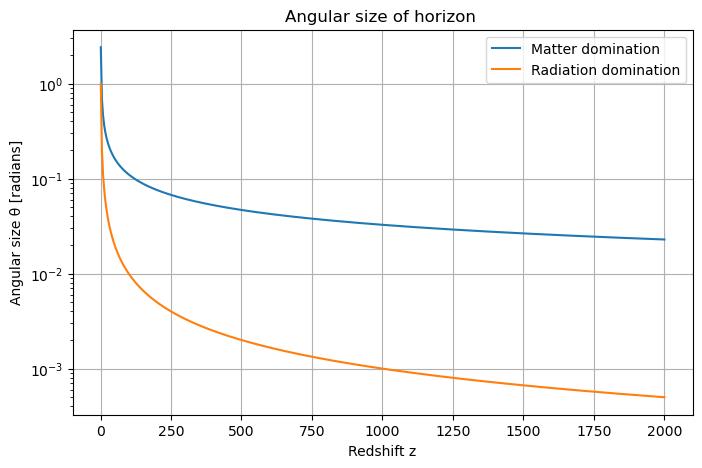

In [95]:
import numpy as np
import matplotlib.pyplot as plt

z_array = np.linspace(1,2000,500)

theta_matter = 1/(np.sqrt(1+z_array)-1)
theta_radiation = 1/z_array

#Plot
plt.figure(figsize=(8,5))
plt.semilogy(z_array, theta_matter, label="Matter domination")
plt.semilogy(z_array, theta_radiation, label="Radiation domination")
plt.xlabel("Redshift z")
plt.ylabel("Angular size θ [radians]")
plt.title("Angular size of horizon ")
plt.legend()
plt.grid()
plt.show()


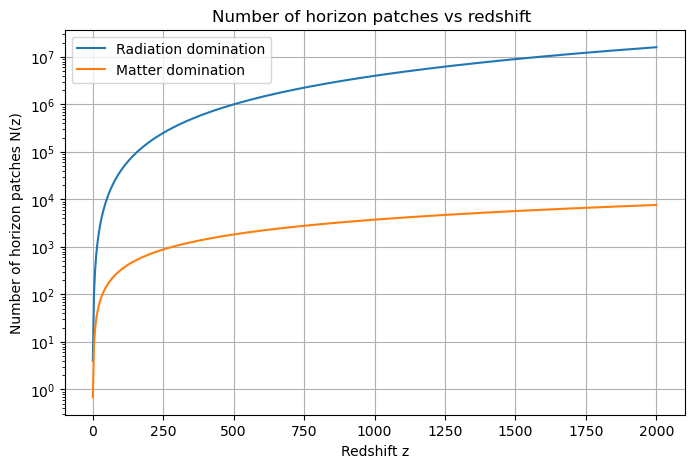

In [96]:
# Calcolo il tiling del cielo, ovvero il numero di patch per ciascun valore di z
N_rad = 4 / theta_radiation**2  
N_mat = 4 / theta_matter**2

#Plot
plt.figure(figsize=(8,5))
plt.semilogy(z_array, N_rad, label="Radiation domination")
plt.semilogy(z_array, N_mat, label="Matter domination")
plt.xlabel("Redshift z")
plt.ylabel("Number of horizon patches N(z)")
plt.title("Number of horizon patches vs redshift ")
plt.grid()
plt.legend()
plt.show()

NB:  
ha senso che N cresca con l'aumnetare di z: più ci spingiamo indietro nel tempo, più piccole sono le regioni causalmente connesse (perché l’universo era giovane) più N  ci servono.  
Inoltre osservo che quando l’universo è dominato dalla radiazione, l’espansione è più rapida rispetto a quando domina la materia -> nella rad.dom. la luce non fa in tempo a viaggiare molto lontano -> orizzonte più piccolo -> più patch indipendenti servono per coprirlo (contro-intuitivo) 
In entrambi i casi, sia per materia che radiazione, N(z recombination)>>1 -> problema dell'orizzonte (ovvero CMB che è pressocche uniforme in tutte le direzioni) !!!!!!!!!!!!!

In [97]:
# Funzione per calcolare la varianza per ciascuna patch
def calculate_patch_variance(theta):
    return theta**2

# Calcolo la varianza per ciascun valore di theta (ogni patch rappresenta una regione del cielo)
patch_variance_matter=[calculate_patch_variance(theta) for theta in theta_matter]
patch_variance_radiation=[calculate_patch_variance(theta) for theta in theta_radiation]

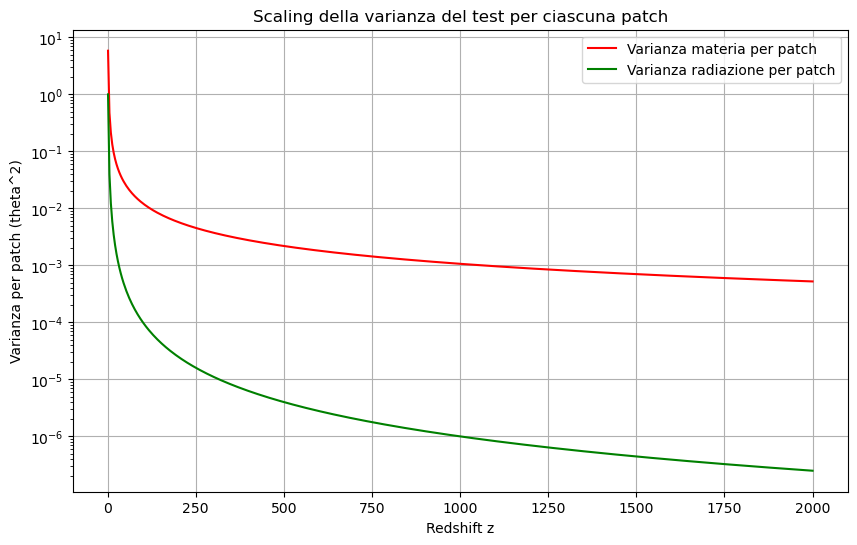

In [98]:
#Plot 
plt.figure(figsize=(10, 6))
plt.semilogy(z_array, patch_variance_matter, label='Varianza materia per patch', color='red')
plt.semilogy(z_array, patch_variance_radiation, label='Varianza radiazione per patch', color='green')
plt.xlabel('Redshift z')
plt.ylabel('Varianza per patch (theta^2)')
plt.title("Scaling della varianza del test per ciascuna patch")
plt.grid(True)
plt.legend()
plt.show()

NB:  
ricordo che la varianza è quanto fluttua una certa grandezza (test statistic) da una patch all’altra.
Sensatamente ottengo che andando verso il passato il numero di patch aumenta -> singolo patch diventa più piccolo angolarmente -> la varianza su ciascun patch cala.  
Mi aspetto che se i patch sono indipendenti ci siano fluttuazioni significative da una patch all’altra -> grossa varianza.   
INVECE ottengo che la varianza cala sì come atteso, ma raggiunge dei valori molto piccoli -> è come se i patch abbiano delle connessioni causali... cosa che effettivamente spiega il comportamento della CMB pressoche omogeneo.  

MA COSA HA CAUSATO QUESTA CONNESSIONE CAUSALE, AVVENUTA PRIMA DELL'EPOCA DI RICOMBINAZIONE (momento formazione CMB) ?????
------> INFLAZIONE 

V. SCALAR FIELD DYNAMICS

In [99]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

# Parametri
m = 1e-6 # massa del campo (scala di inflazione)
t_span = (0, 1e8)
t_eval = np.linspace(*t_span, 1000) 

# Sistema dinamico 
def dynamics_x(t, x):
    x1, x2 = x
    V = 0.5 * m**2 * x1**2
    H = np.sqrt((0.5 * x2**2 + V) / 3)  # equazione di Friedman in unità naturali (massa planck=1)
    dx1dt = x2
    dx2dt = -3 * H * x2 - m**2 * x1  # equazione di campo
    return [dx1dt, dx2dt]

def Hubble_x(x1, x2):
    return np.sqrt((0.5 * x2**2 + 0.5 * m**2 * x1**2) / 3) 


# Parametri di slow-roll
"""
#Caso generale:
def epsilon_x(x1, x2):   
    H_allasec=((0.5*x2**2)+ (0.5*m**2*x1**2))/3
    return x2**2 / (2 * H_allasec)

def eta_from_epsilon(epsilon, H, t):
    log_eps = np.log(epsilon + 1e-12)  # per evitare log(0)
    # Derivata numerica rispetto al tempo
    dlogeps_dt = np.gradient(log_eps, t)
    # dN/dt = H --> d/dN = (1/H) * d/dt
    dlogeps_dN = dlogeps_dt / H
    # Formula finale
    eta = epsilon - 0.5 * dlogeps_dN
    return eta
"""
#Caso specifico del potenziale quadratico: come studiato sul Baumann
def epsilon_x(x1, x2):
    return 2/(x1**2)

def eta(x1,x2):
    return 2/(x1**2)

# Invento diverse condizioni iniziali
initial_conditions = [
    (10, 0),
    #(15, 0),
    (15, 1e-6),
    (20, -1e-6),
]

results_x = []
for x1_0, x2_0 in initial_conditions:
    sol = solve_ivp(dynamics_x, t_span, [x1_0, x2_0], t_eval=t_eval, rtol=1e-8)
    x1 = sol.y[0]
    x2 = sol.y[1]
    t = sol.t
    H_vals = Hubble_x(x1, x2)
    eps_vals = epsilon_x(x1, x2)
    eta_vals = eta(x1,x2)
    #eta_vals = eta_from_epsilon(eps_vals, H_vals, t)
    results_x.append({
        't': sol.t,
        'x1': x1,
        'x2': x2,
        'H': H_vals,
        'epsilon': eps_vals,
        'eta': eta_vals,
        'x1_0': x1_0,
        'x2_0': x2_0
    })


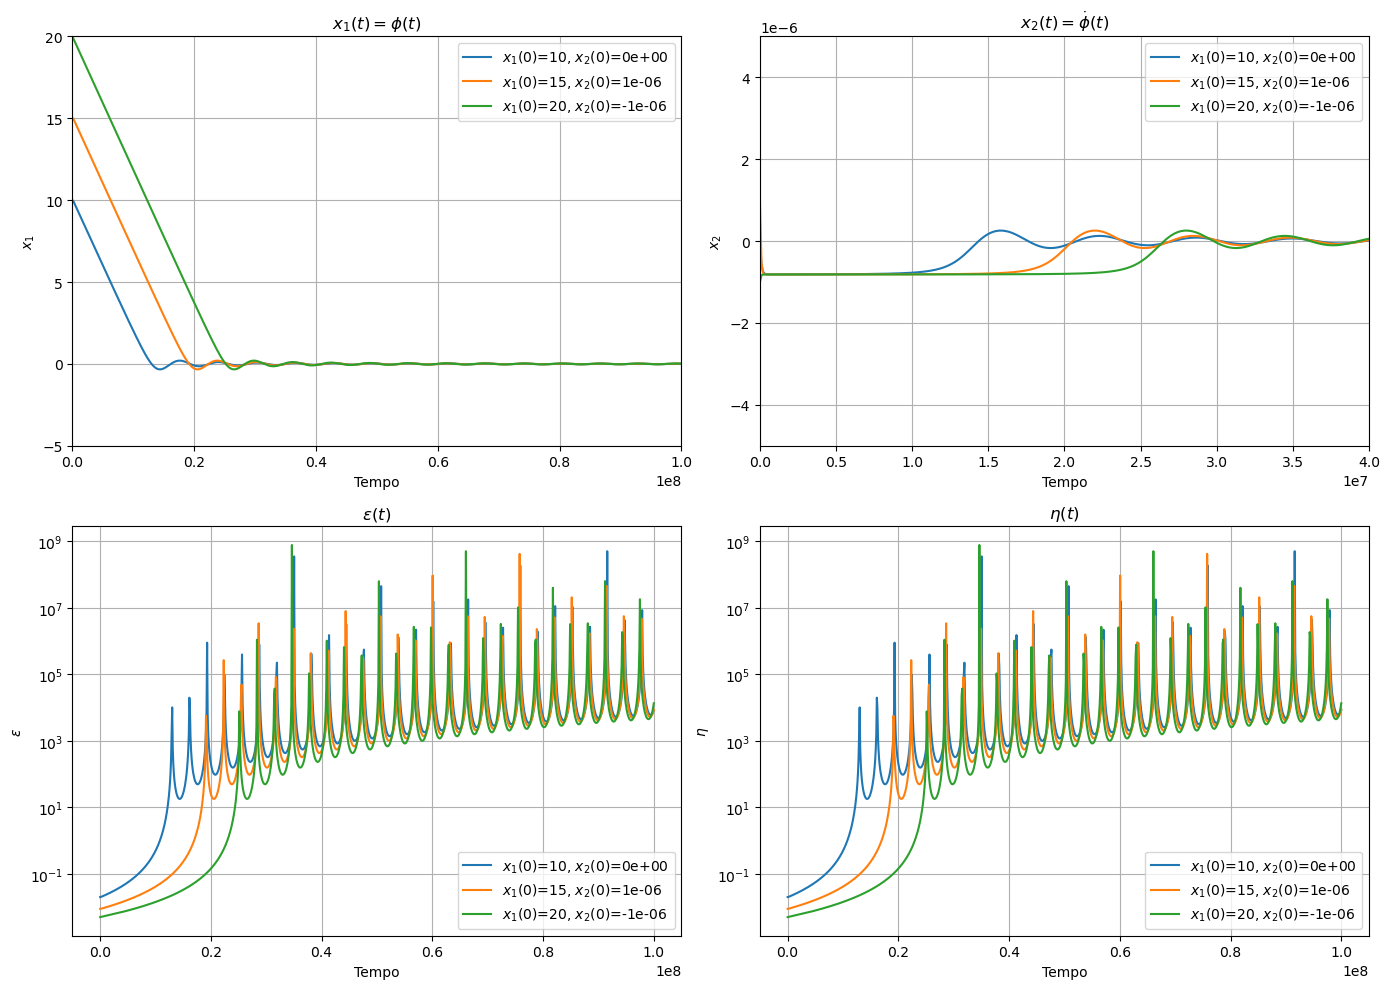

In [100]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

# x1(t) 
for res in results_x:
    axes[0].plot(res['t'], res['x1'], label=f"$x_1(0)$={res['x1_0']}, $x_2(0)$={res['x2_0']:.0e}")
axes[0].set_title(r"$x_1(t) = \phi(t)$")
axes[0].set_xlabel("Tempo")
axes[0].set_ylabel(r"$x_1$")
axes[0].set_ylim(-5, 20)
axes[0].set_xlim(0, 1e8)
axes[0].legend()
axes[0].grid(True)

# x2(t) 
for res in results_x:
    axes[1].plot(res['t'], res['x2'], label=f"$x_1(0)$={res['x1_0']}, $x_2(0)$={res['x2_0']:.0e}")
axes[1].set_title(r"$x_2(t) = \dot{\phi}(t)$")
axes[1].set_xlabel("Tempo")
axes[1].set_ylabel(r"$x_2$")
axes[1].set_ylim(-5e-6, 5e-6)
axes[1].set_xlim(0, 0.4e8)
axes[1].legend()
axes[1].grid(True)

# epsilon(t)
for res in results_x:
    axes[2].plot(res['t'], res['epsilon'], label=f"$x_1(0)$={res['x1_0']}, $x_2(0)$={res['x2_0']:.0e}")
axes[2].set_title(r"$\epsilon(t)$")
axes[2].set_xlabel("Tempo")
axes[2].set_ylabel(r"$\epsilon$")
axes[2].set_yscale("log")
axes[2].legend()
axes[2].grid(True)

# eta(t)
for res in results_x:
    axes[3].plot(res['t'], res['eta'], label=f"$x_1(0)$={res['x1_0']}, $x_2(0)$={res['x2_0']:.0e}")
axes[3].set_title(r"$\eta(t)$")
axes[3].set_xlabel("Tempo")
axes[3].set_ylabel(r"$\eta$")
axes[3].set_yscale("log")
axes[3].legend()
axes[3].grid(True)

plt.tight_layout()
plt.show()


NB:  
1) più grande è $\phi_0$, più a lungo dura l'inflazione (la discesa è più lunga)  
2) la frizione cosmica rallenta il campo all’inizio, poi il potenziale prende il sopravvento (non c'è più slow-roll, ovvero non è più vero che: $\phi ' <<V$)  
3) all'inizio osservo che epsilon<1, ovvero l'inflazione sta avvenenendo; poi quando epsilon>1 e inizia a oscillare e divergere l'inflazione termina

In [101]:
#calcolo il numero di e-folds USANDO ULTIMO PHI_0 INDICATO (20--> N=100, 15--> N=58)

# Verifico se epsilon supera 1 in qualche punto
epsilon_threshold = 1.0
above_threshold = np.where(eps_vals > epsilon_threshold)[0]

if len(above_threshold) > 0:
    # Primo indice in cui epsiolon > 1 ⇒ fine inflazione
    inflation_end_idx = above_threshold[0]
    # Prendo solo l'intervallo inflazionario
    t_inflation = t[:inflation_end_idx + 1]
    H_inflation = H_vals[:inflation_end_idx + 1]
    # Calcolo dell'integrale di e-folds
    N_efolds = np.trapezoid(H_inflation, t_inflation)
else:
    # Se epsilon non supera mai 1, integro su tutto l'intervallo
    N_efolds = np.trapezoid(H_vals, t)

print(f"Numero di e-folds: {N_efolds:.2f}")

Numero di e-folds: 100.28


NB:  
il risultato di e-folds trovato è corente con la condizione iniziale di $\phi_0$=20, come si osserva dalla formula:  
 $N=\frac{\phi_0^2}{4\cdot M_{planck}}-\frac{1}{2}$